# BAB IV: HASIL DAN PEMBAHASAN
## Analisis Persepsi Mahasiswa terhadap Efektivitas Kuliah Online
**Dataset:** Survey Persepsi Mahasiswa (n = 73 responden)  
**Metode Sampling:** Simple Random Sampling (SRS)


In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Global style ──────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', font='DejaVu Sans')
PALETTE_BLUE   = '#2979C4'
PALETTE_TEAL   = '#00897B'
PALETTE_RED    = '#E53935'
PALETTE_ORANGE = '#FB8C00'
PALETTE_PURPLE = '#8E24AA'
BAR_ALPHA      = 0.88
LABEL_FONTSIZE = 10
TITLE_FONTSIZE = 13
AXIS_FONTSIZE  = 11

sheet_id = "1szHiscSNA_h2h1fNcI1SDdXoEIR5ied4moBByB-R3zM"
gid = "1871420219"

url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv&gid={gid}"

df = pd.read_csv(url)
print(f"Dataset berhasil dimuat: {df.shape[0]} baris × {df.shape[1]} kolom")
df.head(3)


Dataset berhasil dimuat: 73 baris × 16 kolom


,Timestamp,Email Address,Prodi,Semester,Kuliah online membuat saya lebih fleksibel dalam mengatur waktu belajar.,Saya merasa lebih mudah memahami materi saat kuliah offline dibanding online.,Interaksi dengan dosen lebih efektif saat kuliah offline.,Kuliah offline membantu saya lebih aktif dalam diskusi.,Koneksi internet menjadi kendala utama dalam kuliah online.,Fasilitas kelas kampus mendukung efektivitas belajar saya saat kuliah offline.,Kuliah online membuat saya lebih cepat lelah secara mental dibanding kuliah offline.,Beban tugas saat kuliah online terasa lebih berat.,"Secara keseluruhan, kuliah online efektif bagi saya.",Saya lebih memilih kuliah offline untuk semester berikutnya.,Model hybrid (campuran) lebih efektif dibanding hanya online atau offline.,"Menurut Anda, apa tantangan utama yang menghambat efektivitas belajar saat kuliah online?"
0,5/6/2026 12:04:30,cloiseshafira105@gmail.com,Sains Data,2,3,3,3,3,3,3,3,3,3,5,3,-
1,5/6/2026 12:23:05,sayadimas599@gmail.com,Teknologi Pengolahan Sawit,2,3,5,5,5,5,5,3,5,1,5,4,tantangan utama saya yang pertama adalah fasil...
2,5/6/2026 12:26:20,caroldupinopereira@gmail.com,Sains Data,2,3,3,4,5,4,4,3,3,3,3,3,Koneksi internet


---
## BAGIAN 1 — Karakteristik Demografi Responden

### 4.1 Sebaran Responden Berdasarkan Semester dan Program Studi

Sebelum memasuki pembahasan substantif terkait persepsi mahasiswa terhadap kuliah online, penting untuk terlebih dahulu memahami profil demografis responden sebagai landasan interpretasi data. Penelitian ini berhasil mengumpulkan sebanyak **73 responden** melalui metode *Simple Random Sampling* (SRS). Namun demikian, sebagaimana tampak pada Gambar 4.1 di bawah ini, distribusi responden tidak menunjukkan sebaran yang merata (*uniform distribution*).

Dari sisi persebaran semester, mayoritas mutlak responden berasal dari mahasiswa **Semester 2**, yakni sebanyak **61 orang (83,6%)**, sementara mahasiswa semester 3, 4, 6, dan 8 masing-masing hanya berkontribusi dalam jumlah yang sangat kecil (1–5 orang). Kondisi serupa juga ditemukan pada distribusi program studi: **Sains Data** mendominasi dengan **28 responden (38,4%)**, diikuti oleh Teknik Pertambangan (10 orang), Informatika dan Teknologi Pengolahan Sawit (masing-masing 6 orang), serta program studi lainnya dengan representasi di bawah 5 orang.

Ketimpangan distribusi ini merupakan implikasi langsung dari keterbatasan penerapan SRS di lingkungan yang tidak sepenuhnya homogen. Dalam teori sampling, SRS mengasumsikan setiap anggota populasi memiliki probabilitas yang sama untuk terpilih (*equal probability of selection*). Akan tetapi, dalam praktiknya, aksesibilitas responden—baik secara sosial maupun jaringan distribusi kuesioner—seringkali terpusat pada kelompok tertentu, sehingga menghasilkan *non-proportional representation*. Oleh karena itu, hasil penelitian ini perlu diinterpretasikan dengan mempertimbangkan bahwa temuan yang diperoleh cenderung lebih representatif bagi mahasiswa **Semester 2 dari Program Studi Sains Data**, dan generalisasinya ke populasi yang lebih luas harus dilakukan dengan kehati-hatian metodologis (*methodological caution*).


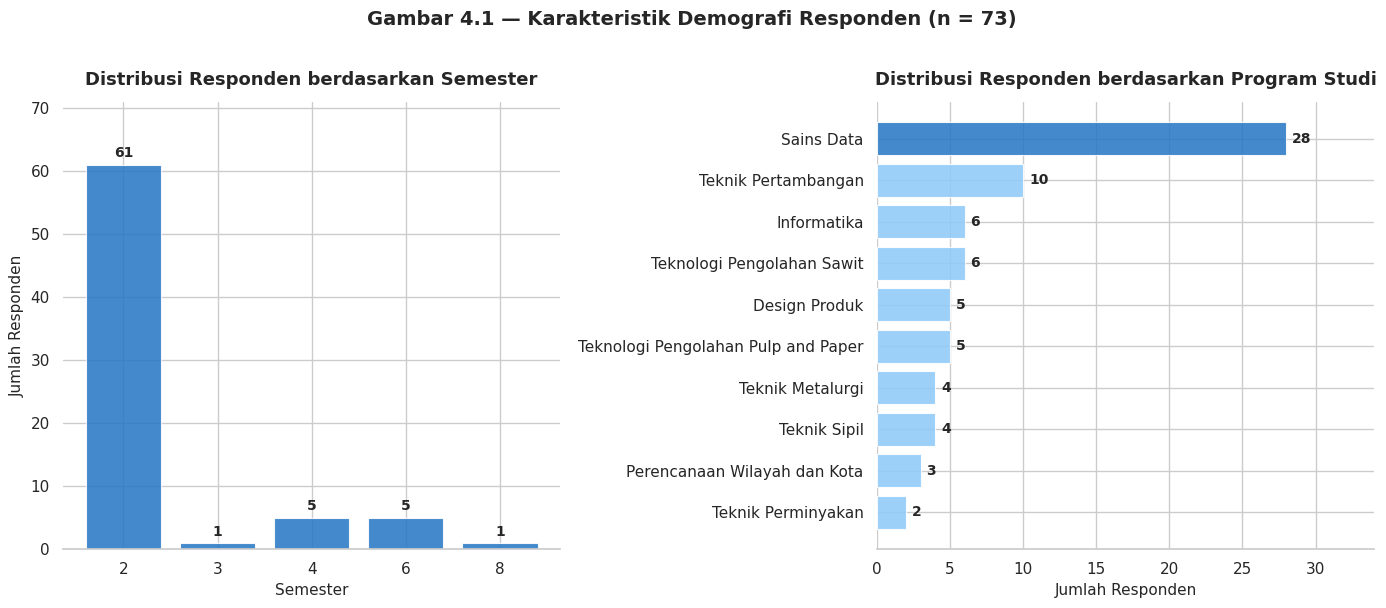

✔ Gambar 4.1 tersimpan.


In [18]:
# ── Bagian 1 · Demografi ─────────────────────────────────────────────────────
sem_counts   = df['Semester'].value_counts().sort_index()
prodi_counts = df['Prodi'].value_counts().sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Gambar 4.1 — Karakteristik Demografi Responden (n = 73)',
             fontsize=14, fontweight='bold', y=1.01)

# ── Kiri: Distribusi Semester (Bar Chart vertikal) ────────────────────────────
ax1 = axes[0]
bars1 = ax1.bar([str(s) for s in sem_counts.index], sem_counts.values,
                color=PALETTE_BLUE, alpha=BAR_ALPHA, edgecolor='white', linewidth=0.8)
for bar in bars1:
    h = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width() / 2, h + 0.7,
             str(int(h)), ha='center', va='bottom',
             fontsize=LABEL_FONTSIZE, fontweight='bold')
ax1.set_title('Distribusi Responden berdasarkan Semester',
              fontsize=TITLE_FONTSIZE, fontweight='bold', pad=12)
ax1.set_xlabel('Semester', fontsize=AXIS_FONTSIZE)
ax1.set_ylabel('Jumlah Responden', fontsize=AXIS_FONTSIZE)
ax1.set_ylim(0, sem_counts.max() + 10)
ax1.yaxis.set_major_locator(mticker.MultipleLocator(10))
sns.despine(ax=ax1, left=True)

# ── Kanan: Distribusi Prodi (Horizontal Bar Chart) ───────────────────────────
ax2 = axes[1]
colors2 = [PALETTE_BLUE if v == prodi_counts.max() else '#90CAF9' for v in prodi_counts.values]
bars2 = ax2.barh(prodi_counts.index, prodi_counts.values,
                 color=colors2, alpha=BAR_ALPHA, edgecolor='white', linewidth=0.8)
for bar in bars2:
    w = bar.get_width()
    ax2.text(w + 0.4, bar.get_y() + bar.get_height() / 2,
             str(int(w)), ha='left', va='center',
             fontsize=LABEL_FONTSIZE, fontweight='bold')
ax2.set_title('Distribusi Responden berdasarkan Program Studi',
              fontsize=TITLE_FONTSIZE, fontweight='bold', pad=12)
ax2.set_xlabel('Jumlah Responden', fontsize=AXIS_FONTSIZE)
ax2.set_ylabel('')
ax2.set_xlim(0, prodi_counts.max() + 6)
sns.despine(ax=ax2, left=True)

plt.tight_layout()
plt.show()
print("✔ Gambar 4.1 tersimpan.")


---
## BAGIAN 2 — Kesimpulan Umum Persepsi Efektivitas Kuliah Online

### 4.2 Distribusi Persepsi Mahasiswa terhadap Efektivitas Kuliah Online Secara Keseluruhan


Pertanyaan inti penelitian ini adalah sejauh mana mahasiswa mempersepsikan kuliah online sebagai modalitas belajar yang efektif. Responden diminta memberikan penilaian pada skala Likert 1 hingga 5 terhadap pernyataan: *"Secara keseluruhan, kuliah online efektif bagi saya."* Hasil distribusi frekuensi, sebagaimana tersaji pada Gambar 4.2, menunjukkan kecenderungan yang cukup tegas ke arah persepsi **negatif**.

Sebanyak **21 responden (28,8%)** memilih skala **1** (*sangat tidak setuju*) dan **26 responden (35,6%)** memilih skala **2** (*tidak setuju*). Gabungan keduanya membentuk kelompok persepsi negatif yang mencapai **64,4% dari total responden**—sebuah proporsi yang secara statistik sangat signifikan. Di sisi lain, hanya **5 responden (6,8%)** yang memilih skala **4** dan **2 responden (2,7%)** yang memilih skala **5**, menandakan tingkat kepuasan yang amat rendah terhadap kuliah online.

Temuan ini memiliki resonansi yang kuat apabila dikaitkan dengan komposisi demografis responden yang didominasi oleh **mahasiswa Semester 2**. Secara teoritis, mahasiswa pada semester awal perkuliahan sedang mengalami fase transisi kritis dari jenjang pendidikan menengah (*secondary education*) ke jenjang pendidikan tinggi (*higher education*). Dalam fase ini, mahasiswa umumnya masih bergantung pada struktur belajar yang terorganisir secara eksternal (*extrinsic structure*)—seperti kehadiran fisik di kelas, bimbingan langsung dari pengajar, dan interaksi sosial dengan teman sebaya—sebagaimana yang lazim dijumpai di lingkungan sekolah. Format kuliah online, yang menuntut kemandirian belajar (*self-directed learning*) dan kemampuan manajemen waktu yang tinggi, bertentangan dengan pola kebiasaan belajar yang baru saja mereka tinggalkan. Kondisi ini sejalan dengan konsep *adjustment shock* dalam literatur transisi akademik, di mana mahasiswa baru seringkali merasa kewalahan (*overwhelmed*) saat dihadapkan pada tuntutan otonomi akademik yang meningkat secara drastis.


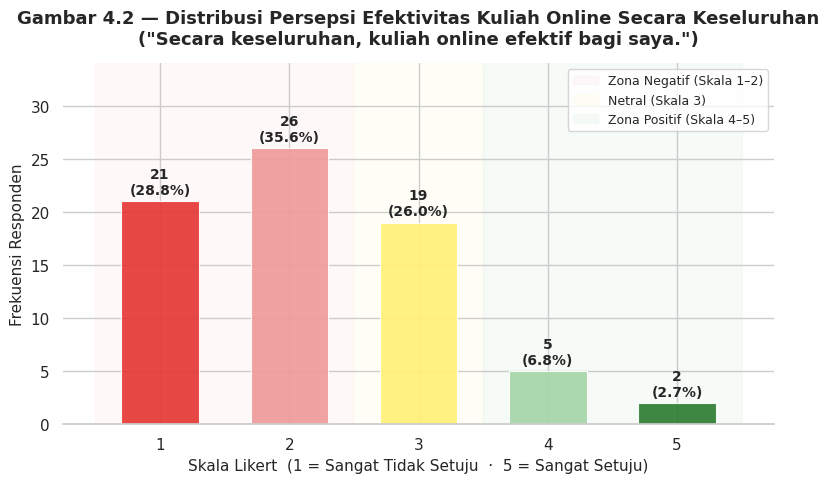

✔ Gambar 4.2 tersimpan.


In [19]:
# ── Bagian 2 · Persepsi Umum Efektivitas ─────────────────────────────────────
col_efektif = 'Secara keseluruhan, kuliah online efektif bagi saya.'
freq2 = df[col_efektif].value_counts().sort_index()

color_map2 = {1: '#E53935', 2: '#EF9A9A', 3: '#FFF176', 4: '#A5D6A7', 5: '#2E7D32'}
bar_colors2 = [color_map2[k] for k in freq2.index]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar([str(k) for k in freq2.index], freq2.values,
              color=bar_colors2, alpha=0.92, edgecolor='white', linewidth=0.8, width=0.6)
for bar in bars:
    h = bar.get_height()
    pct = h / 73 * 100
    ax.text(bar.get_x() + bar.get_width() / 2, h + 0.4,
            f'{int(h)}\n({pct:.1f}%)', ha='center', va='bottom',
            fontsize=LABEL_FONTSIZE, fontweight='bold')

ax.set_title('Gambar 4.2 — Distribusi Persepsi Efektivitas Kuliah Online Secara Keseluruhan\n'
             '("Secara keseluruhan, kuliah online efektif bagi saya.")',
             fontsize=TITLE_FONTSIZE, fontweight='bold', pad=14)
ax.set_xlabel('Skala Likert  (1 = Sangat Tidak Setuju  ·  5 = Sangat Setuju)', fontsize=AXIS_FONTSIZE)
ax.set_ylabel('Frekuensi Responden', fontsize=AXIS_FONTSIZE)
ax.set_ylim(0, freq2.max() + 8)
ax.yaxis.set_major_locator(mticker.MultipleLocator(5))

# Anotasi zona sentimen
ax.axvspan(-0.5, 1.5, color='#FFEBEE', alpha=0.35, zorder=0, label='Zona Negatif (Skala 1–2)')
ax.axvspan(1.5, 2.5, color='#FFFDE7', alpha=0.35, zorder=0, label='Netral (Skala 3)')
ax.axvspan(2.5, 4.5, color='#E8F5E9', alpha=0.35, zorder=0, label='Zona Positif (Skala 4–5)')
ax.legend(fontsize=9, loc='upper right')
sns.despine(ax=ax, left=True)

plt.tight_layout()
plt.show()
print("✔ Gambar 4.2 tersimpan.")


---
## BAGIAN 3 — Analisis Faktor Pendukung & Kendala Utama (Detail Likert)

### 4.3 Faktor Teknis dan Pedagogis sebagai Akar Penyebab Ketidakefektifan Kuliah Online

Guna memahami lebih dalam mengapa kuliah online dinilai tidak efektif, analisis dilanjutkan pada dua variabel Likert yang secara konseptual berperan sebagai **faktor penyebab** (*root causes*): kendala koneksi internet dan kenyamanan pemahaman materi secara offline. Gambar 4.3 menyajikan distribusi frekuensi kedua variabel tersebut secara bersandingan.

**Pertama, kendala koneksi internet.** Distribusi pernyataan *"Koneksi internet menjadi kendala utama dalam kuliah online"* menunjukkan pola yang sangat condong ke arah setuju: **32 responden (43,8%)** memilih skala **5** (*sangat setuju*) dan **10 responden (13,7%)** memilih skala **4**, sehingga proporsi responden yang mengakui internet sebagai kendala kritis mencapai **57,5%**. Temuan ini menunjukkan bahwa infrastruktur digital yang tidak memadai merupakan hambatan struktural yang nyata (*real structural barrier*) bagi efektivitas pembelajaran daring. Ketergantungan kuliah online pada konektivitas jaringan yang stabil menjadikannya modalitas yang sensitif terhadap ketimpangan akses digital (*digital divide*), khususnya bagi mahasiswa yang berdomisili di wilayah dengan cakupan jaringan yang terbatas.

**Kedua, preferensi pemahaman materi secara offline.** Distribusi pernyataan *"Saya merasa lebih mudah memahami materi saat kuliah offline dibanding online"* bahkan lebih ekstrem: **39 responden (53,4%)** memilih skala **5** (*sangat setuju*) dan **16 responden (21,9%)** memilih skala **4**, menjadikan total proporsi yang lebih memilih offline mencapai **75,3%**. Angka ini mencerminkan bahwa kuliah tatap muka masih dipandang sebagai modalitas belajar yang lebih superior dalam hal pencapaian pemahaman kognitif. Hal ini dapat dijelaskan melalui perspektif *embodied cognition* dan *social learning theory*: interaksi fisik, bahasa tubuh dosen, dan diskusi kelas yang bersifat spontan memberikan *multimodal cues* yang sulit direplikasi oleh platform digital. Kedua temuan ini, secara bersama-sama, membentuk gambaran bahwa permasalahan kuliah online bersifat **dua lapis**: hambatan teknis di satu sisi, dan hambatan pedagogis di sisi lain.


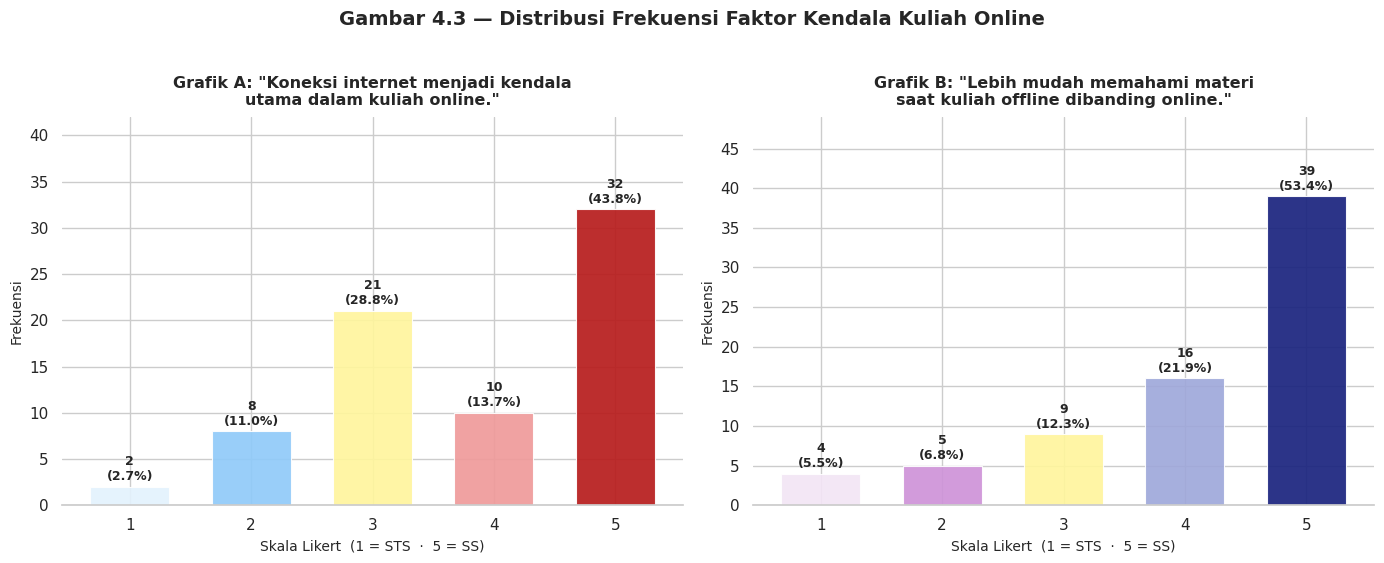

✔ Gambar 4.3 tersimpan.


In [20]:
# ── Bagian 3 · Faktor Kendala ────────────────────────────────────────────────
col_internet = 'Koneksi internet menjadi kendala utama dalam kuliah online.'
col_offline  = 'Saya merasa lebih mudah memahami materi saat kuliah offline dibanding online.'

freq_inet = df[col_internet].value_counts().sort_index()
freq_off  = df[col_offline].value_counts().sort_index()

# Pastikan semua skala 1-5 ada
for col_freq in [freq_inet, freq_off]:
    for k in range(1, 6):
        if k not in col_freq.index:
            col_freq[k] = 0
freq_inet = freq_inet.sort_index()
freq_off  = freq_off.sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.suptitle('Gambar 4.3 — Distribusi Frekuensi Faktor Kendala Utama Kuliah Online',
             fontsize=14, fontweight='bold', y=1.02)

def plot_likert(ax, freq, title, color_hi, color_lo):
    color_map = {1: color_lo[0], 2: color_lo[1], 3: '#FFF59D',
                 4: color_hi[1], 5: color_hi[0]}
    bcolors = [color_map[k] for k in freq.index]
    bars = ax.bar([str(k) for k in freq.index], freq.values,
                  color=bcolors, alpha=0.92, edgecolor='white', linewidth=0.8, width=0.65)
    for bar in bars:
        h = bar.get_height()
        pct = h / 73 * 100
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.4,
                f'{int(h)}\n({pct:.1f}%)', ha='center', va='bottom',
                fontsize=9, fontweight='bold')
    ax.set_title(title, fontsize=11.5, fontweight='bold', pad=10, wrap=True)
    ax.set_xlabel('Skala Likert  (1 = STS  ·  5 = SS)', fontsize=10)
    ax.set_ylabel('Frekuensi', fontsize=10)
    ax.set_ylim(0, freq.max() + 10)
    ax.yaxis.set_major_locator(mticker.MultipleLocator(5))
    sns.despine(ax=ax, left=True)

plot_likert(axes[0], freq_inet,
            'Grafik A: "Koneksi internet menjadi kendala\nutama dalam kuliah online."',
            ['#B71C1C', '#EF9A9A'], ['#E3F2FD', '#90CAF9'])

plot_likert(axes[1], freq_off,
            'Grafik B: "Lebih mudah memahami materi\nsaat kuliah offline dibanding online."',
            ['#1A237E', '#9FA8DA'], ['#F3E5F5', '#CE93D8'])

plt.tight_layout()
plt.show()
print("✔ Gambar 4.3 tersimpan.")


---
## BAGIAN 4 — Pendalaman Kualitatif: Tantangan Utama Versi Mahasiswa

### 4.4 Analisis Tematik Pertanyaan Terbuka: Suara Langsung dari Mahasiswa


Untuk melengkapi dan memperkuat temuan kuantitatif yang telah dipaparkan pada sub-bab sebelumnya, penelitian ini juga menyertakan sebuah pertanyaan terbuka (*open-ended question*): *"Menurut Anda, apa tantangan utama yang menghambat efektivitas belajar saat kuliah online?"* Jawaban-jawaban tekstual dari 73 responden kemudian dianalisis menggunakan teknik **keyword coding** dan **thematic categorization**, yakni suatu proses pengkodean induktif di mana setiap respons diidentifikasi kata kunci dominannya, lalu dikelompokkan ke dalam tema-tema yang lebih besar (*thematic clusters*).

Hasil kategorisasi tersebut tersaji pada Gambar 4.4 di bawah ini, yang dengan gamblang memperlihatkan hierarki tantangan dari perspektif mahasiswa itu sendiri.

**Jaringan/Sinyal/Internet** menduduki posisi teratas dengan frekuensi kemunculan **40 kali**, memvalidasi temuan kuantitatif pada Bagian 3 bahwa kendala teknis bersifat dominan dan bukan sekadar persepsi individual, melainkan pengalaman kolektif yang dialami oleh hampir seluruh mahasiswa. Keluhan kedua yang paling sering muncul adalah **Kurangnya Interaksi dengan Dosen** (28 kali), yang mengindikasikan bahwa mahasiswa merindukan dimensi relasional dalam pembelajaran—sesuatu yang sulit digantikan oleh medium digital. Temuan ini sejalan dengan konsep *social presence theory* dalam pendidikan daring, yang menyatakan bahwa absennya kehadiran sosial (*social presence*) secara langsung menurunkan keterlibatan dan motivasi belajar.

Tantangan ketiga, **Fokus/Distraksi/Lingkungan Rumah** (26 kali), merefleksikan realitas bahwa rumah sebagai ruang belajar belum sepenuhnya siap (*not learning-ready*) bagi banyak mahasiswa. Batas antara ruang pribadi dan ruang akademis yang kabur (*blurred boundaries*) menciptakan gangguan kognitif yang terus-menerus. Sementara itu, **Beban Tugas dan Materi** (21 kali) menunjukkan bahwa persepsi tentang meningkatnya tuntutan akademis di era daring turut berkontribusi pada stres belajar mahasiswa. Terakhir, **Disiplin dan Motivasi Diri** (14 kali) melengkapi gambaran ini: tanpa struktur eksternal yang memaksa kehadiran fisik, banyak mahasiswa—terutama mereka yang baru memasuki jenjang perguruan tinggi—berjuang untuk mempertahankan konsistensi dan semangat belajar secara mandiri.

Secara keseluruhan, narasi kualitatif yang terangkum dalam Gambar 4.4 tidak sekadar mengonfirmasi data angka, tetapi juga memberikan dimensi kemanusiaan (*human dimension*) yang penting: di balik setiap nilai skala Likert yang rendah, terdapat mahasiswa yang berjuang dengan sinyal yang putus-putus, merindukan penjelasan langsung dari dosen, berusaha berkonsentrasi di tengah keramaian rumah, dan mencoba memompa semangat belajarnya sendiri. Temuan ini menjadi pengingat bahwa efektivitas pendidikan tidak dapat dilepaskan dari kondisi ekologis dan sosial tempat pembelajaran itu berlangsung.


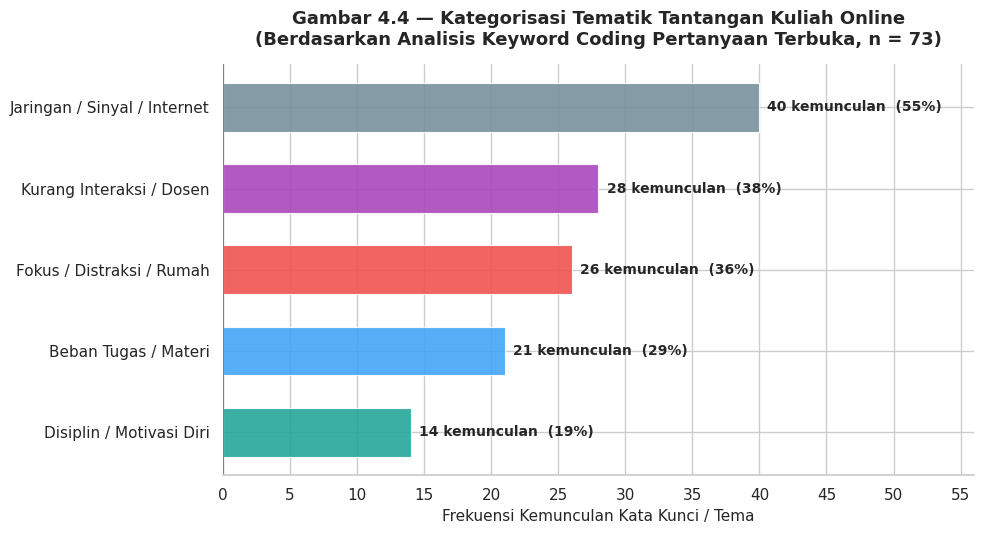

✔ Gambar 4.4 tersimpan.


In [21]:
# ── Bagian 4 · Analisis Kualitatif ──────────────────────────────────────────
kategori  = [
    'Jaringan / Sinyal / Internet',
    'Kurang Interaksi / Dosen',
    'Fokus / Distraksi / Rumah',
    'Beban Tugas / Materi',
    'Disiplin / Motivasi Diri',
]
frekuensi = [40, 28, 26, 21, 14]

# Urutkan dari terkecil → terbesar agar bar terpanjang ada di atas
sorted_pairs = sorted(zip(frekuensi, kategori))
freq_sorted = [p[0] for p in sorted_pairs]
kat_sorted  = [p[1] for p in sorted_pairs]

palette4 = ['#78909C', '#AB47BC', '#EF5350', '#42A5F5', '#26A69A']

fig, ax = plt.subplots(figsize=(10, 5.5))
bars = ax.barh(kat_sorted, freq_sorted,
               color=list(reversed(palette4)), alpha=0.90,
               edgecolor='white', linewidth=0.8, height=0.6)
for bar in bars:
    w = bar.get_width()
    pct = w / 73 * 100          # relatif terhadap jumlah responden
    ax.text(w + 0.6, bar.get_y() + bar.get_height() / 2,
            f'{int(w)} kemunculan  ({pct:.0f}%)', ha='left', va='center',
            fontsize=10, fontweight='bold')

ax.set_title('Gambar 4.4 — Kategorisasi Tematik Tantangan Kuliah Online\n'
             '(Berdasarkan Analisis Keyword Pertanyaan Terbuka, n = 73)',
             fontsize=13, fontweight='bold', pad=14)
ax.set_xlabel('Frekuensi Kemunculan Kata Kunci / Tema', fontsize=AXIS_FONTSIZE)
ax.set_ylabel('')
ax.set_xlim(0, max(freq_sorted) + 16)
ax.xaxis.set_major_locator(mticker.MultipleLocator(5))
ax.axvline(x=0, color='grey', linewidth=0.8)
sns.despine(ax=ax, left=True)

plt.tight_layout()
plt.show()
print("✔ Gambar 4.4 tersimpan.")


---
## Ringkasan Temuan

| Temuan | Nilai / Proporsi |
|---|---|
| Total Responden | 73 |
| Didominasi Semester 2 | 61 orang (83,6%) |
| Program Studi terbanyak (Sains Data) | 28 orang (38,4%) |
| Persepsi negatif efektivitas kuliah online (Skala 1+2) | 47 orang (64,4%) |
| Mengakui internet sebagai kendala (Skala 4+5) | 42 orang (57,5%) |
| Merasa lebih mudah belajar offline (Skala 4+5) | 55 orang (75,3%) |
| Tantangan terbanyak (Kualitatif) | Jaringan/Internet (40 kemunculan) |

> **Catatan Metodologis:** Hasil penelitian ini perlu diinterpretasikan dengan mempertimbangkan keterbatasan sebaran SRS. Generalisasi ke populasi yang lebih luas memerlukan penelitian lanjutan dengan sampling yang lebih proporsional.
